(sec:eigenvalue_algorithms)=

# Eigenvalue Algorithms

Eigenvalue problems are central to many areas of chemistry, including
quantum mechanics, spectroscopy, molecular vibrations, reaction networks,
and data analysis. In this section, we introduce two numerical
approaches for eigenvalue problems: power iteration and the QR algorithm.

## Theoretical Foundations

For a square matrix $\bm{A}$, an eigenvector $\vec{v}$ is a non-zero vector
whose direction is unchanged by multiplication with $\bm{A}$:

```{math}
:enumerated: true
:label: eq:eigenvalue_definition
\bm{A}\vec{v} = \lambda \vec{v} \, .
```

The scalar $\lambda$ is the corresponding eigenvalue. The two algorithms below
use this equation in different ways. Power iteration finds one dominant
eigenvector by repeated matrix-vector multiplication. The QR algorithm
transforms the whole matrix until its eigenvalues can be read from the
diagonal.


If a matrix has a complete set of linearly independent eigenvectors, we can
collect these eigenvectors as columns of a matrix $\bm{Q}$ and the eigenvalues
in a diagonal matrix $\bm{\Lambda}$. The matrix can then be written as
$$
\bm{A} = \bm{Q}\bm{\Lambda}\bm{Q}^{-1} \, .
$$
This is called the *eigenvalue decomposition* of $\bm{A}$. 

:::{note} Eigenvalue Decomposition of Real Symmetric Matrices
:class: dropdown
For real symmetric matrices, the eigenvectors can be chosen orthonormal.
This means that $\bm{Q}$ is an orthogonal matrix, *i.e.*
$$
\bm{Q} \bm{Q}^\intercal = 1\kern-0.25em\text{l} = \bm{Q}^\intercal \bm{Q} \, ,
$$
where $1\kern-0.25em\text{l}$ is the identity matrix. 
This implies that the inverse of $\bm{Q}$ is simply its transpose: 
$\bm{Q}^{-1} = \bm{Q}^\intercal$.
Thus, the eigenvalue decomposition of a real symmetric matrix can be written as
$$
\bm{A} = \bm{Q}\bm{\Lambda}\bm{Q}^\intercal \, .
$$
:::

### Power Iteration

Power iteration starts from a vector $\vec{x}_0$ and repeatedly multiplies it by the matrix:

```{math}
:enumerated: true
:label: eq:power_iteration
\vec{x}_{k+1}
=
\frac{\bm{A}\vec{x}_k}{\|\bm{A}\vec{x}_k\|};
\quad k = 0, 1, 2, \ldots\,.
```
If the matrix has one dominant eigenvalue, meaning one eigenvalue whose 
absolute value is larger than all the others, the direction of $\vec{x}_k$ 
approaches the corresponding eigenvector, given the starting vector 
is not orthogonal to it.
Though mathematically not necessary, the normalisation of the iterate
by its norm is important for numerical stability. It prevents the vector from
growing too large or too small, which could lead to overflow or underflow in
finite-precision arithmetic.

Once the vector has converged, the eigenvalue can be estimated with the
Rayleigh quotient:
```{math}
:enumerated: true
:label: eq:rayleigh_quotient
\lambda
=
\frac{\vec{x}^{\dag}\bm{A}\vec{x}}
{\vec{x}^{\dag}\vec{x}} \, .
```
This eigenvalue is dominant in absolute value. Its absolute value is called
the [*spectral radius*](wiki:Spectral_radius) of $\bm{A}$, denoted as
$\rho(\bm{A})$.

:::{tip} Convergence proof of Power Iteration
:class: dropdown

Assume that the eigenvectors of $\bm{A}$ form a basis and that the eigenvalues
are ordered by magnitude,
$|\lambda_1| > |\lambda_2| \geq \cdots \geq |\lambda_n|$. The starting vector
can then be written as a linear combination of eigenvectors,

$$
\vec{x}_0 = \sum_{i=1}^{n} a_i \vec{v}_i \, .
$$

After repeatedly applying the matrix, we obtain

$$
\bm{A}^{k}\vec{x}_0
=
\lambda_1^k
\left[
a_1\vec{v}_1
+
\sum_{i=2}^{n}
\left(\frac{\lambda_i}{\lambda_1}\right)^k
a_i\vec{v}_i
\right] \, .
$$

Because $|\lambda_i / \lambda_1| < 1$ for all $i > 1$, the remaining terms
become smaller as $k$ increases. The direction therefore approaches the
dominant eigenvector $\vec{v}_1$. 
:::

### QR Algorithm

Power iteration gives only one eigenpair. If we want all eigenvalues of a
matrix, we need a different idea. The QR algorithm repeatedly performs the 
[_QR decomposition_](wiki:QR_decomposition) of the matrix:
$$
\bm{A}_k = \bm{Q}_k \bm{R}_k
$$

and then multiplies the factors in reverse order:

```{math}
:enumerated: true
:label: eq:qr_iteration
\bm{A}_{k+1} = \bm{R}_k \bm{Q}_k \, .
```

For [*normal matrices*](wiki:normal_matrix), in particular real symmetric matrices 
whose eigenvalues have distinct absolute values, the QR iteration approaches a 
diagonal matrix without changing the eigenvalues. 
The eigenvalues of $\bm{A}_0$ can therefore be read from the diagonal of 
$\bm{A}_k$ for sufficiently large $k$.

The following figure shows the same idea visually. We start from a symmetric
$8 \times 8$ matrix and apply the QR iteration repeatedly. The colours show
the matrix entries. As the iteration proceeds, the off-diagonal entries become
smaller and the eigenvalues move onto the diagonal.

In [1]:
import altair as alt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

slider_style = """
<style>
.vega-bindings {
  width: min(360px, 100%);
  margin: 0.75rem 0 0 34px;
}
.vega-bind {
  display: flex;
  align-items: center;
  width: 100%;
  font-size: 18px;
  line-height: 1.2;
  white-space: nowrap;
}
.vega-bind input[type="range"] {
  flex: 1 1 auto;
  min-width: 220px;
  margin-left: 0.35rem;
  margin-right: 0.75rem;
  transform: translateY(2.4px);
}
.vega-bind input[type="number"] {
  width: 3.25rem;
  font-size: 16px;
  line-height: 1.2;
  text-align: center;
}
</style>
"""

display(HTML(slider_style))

rng = np.random.default_rng(8)
q, _ = np.linalg.qr(rng.normal(size=(8, 8)))
eigvals = np.array([4.0, -3.88, 3.55, -3.32, 2.95, -2.70, 2.35, -2.05])
a_qr_demo = q @ np.diag(eigvals) @ q.T

records = []
a_k = a_qr_demo.copy()
for k in range(65):
    for row in range(a_k.shape[0]):
        for column in range(a_k.shape[1]):
            records.append({
                "k": k,
                "row": row,
                "column": column,
                "value": a_k[row, column],
            })

    q_k, r_k = np.linalg.qr(a_k)
    a_k = r_k @ q_k

qr_iterations = pd.DataFrame(records)

k_slider = alt.param(
    name="k",
    value=0,
    bind=alt.binding_range(min=0, max=64, step=1, name="𝑘 = "),
)

chart = (
    alt.Chart(qr_iterations)
    .mark_rect(stroke="white", strokeWidth=0.5)
    .encode(
        x=alt.X(
            "column:O",
            axis=alt.Axis(
                title=None,
                orient="top",
                labelAngle=0,
                labelFontSize=15,
            ),
        ),
        y=alt.Y(
            "row:O",
            axis=alt.Axis(title=None, labelFontSize=15),
            sort="ascending",
        ),
        color=alt.Color(
            "value:Q",
            scale=alt.Scale(
                domain=[-4, 0, 4],
                range=["#3c4cc0", "#dddddd", "#bf0026"],
            ),
            legend=alt.Legend(
                title=None,
                labelFontSize=15,
                labelOffset=6,
                gradientLength=300,
                gradientThickness=18,
                gradientStrokeColor="black",
                gradientStrokeWidth=0.8,
            ),
        ),
        tooltip=[
            alt.Tooltip("row:O", title="row"),
            alt.Tooltip("column:O", title="column"),
            alt.Tooltip("value:Q", title="value", format=".3f"),
        ],
    )
    .add_params(k_slider)
    .transform_filter(alt.datum.k == k_slider)
    .properties(width=300, height=300)
    .configure_view(stroke="black", strokeWidth=1)
)

chart


alt.Chart(...)

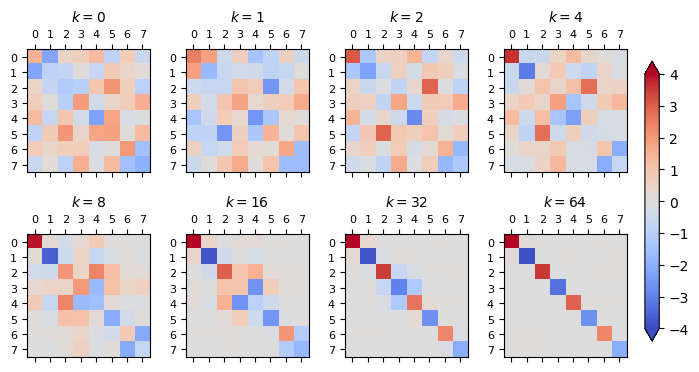

In [31]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(8)
q, _ = np.linalg.qr(rng.normal(size=(8, 8)))
eigvals = np.array([4.0, -3.88, 3.55, -3.32, 2.95, -2.70, 2.35, -2.05])
a_qr_demo = q @ np.diag(eigvals) @ q.T

snapshot_iterations = [0, 1, 2, 4, 8, 16, 32, 64]
snapshots = {0: a_qr_demo.copy()}

a_k = a_qr_demo.copy()
for k in range(1, max(snapshot_iterations) + 1):
    q_k, r_k = np.linalg.qr(a_k)
    a_k = r_k @ q_k
    if k in snapshot_iterations:
        snapshots[k] = a_k.copy()

fig, axes = plt.subplots(2, 4, figsize=(8.0, 4.0))

for ax, k in zip(axes.ravel(), snapshot_iterations):
    image = ax.matshow(snapshots[k], cmap="coolwarm", vmin=-4, vmax=4)
    ax.set_title(f"$k = {k}$", fontsize=10)
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=0.25, hspace=0.50, right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.018, 0.70])
_ = fig.colorbar(image, cax=cbar_ax, extend="both")
plt.show()


For a normal matrix, the same QR factors also contain information about the
eigenvectors. If the QR iteration converges to a diagonal matrix, the accumulated
product of the unitary matrices approaches the matrix of eigenvectors:

```{math}
:enumerated: true
:label: eq:qr_eigenvectors
\bm{V}
\approx
\bm{Z}_k
=
\bm{Q}_0\bm{Q}_1\cdots\bm{Q}_{k-1}\bm{Q}_k,
\quad
\bm{A}_0\bm{Z}_k
\approx
\bm{Z}_k\bm{\Lambda} \, .
```

Thus, the columns of $\bm{Z}_k$ are approximate eigenvectors of the original
matrix $\bm{A}_0$, ordered consistently with the diagonal entries of the
converged matrix.

:::{note} Normal Matrices
:class: dropdown
A matrix $\bm{A}$ is called normal if it commutes with 
its conjugate transpose, *i.e.*
$$
\bm{A}\bm{A}^\dagger = \bm{A}^\dagger\bm{A} \, .
$$
Normal matrices include but are not limited to
real symmetric, complex Hermitian, and unitary matrices.
:::

:::{tip} Convergence of the QR Algorithm
:class: dropdown

The QR iteration has two separate ideas. First, each iteration preserves the
eigenvalues. Second, under additional assumptions, the sequence of matrices
approaches a form from which the eigenvalues can be read directly.

To see why the eigenvalues are preserved, use the QR decomposition
$\bm{A}_k = \bm{Q}_k\bm{R}_k$. Since $\bm{Q}_k$ is unitary, we can write
$\bm{R}_k = \bm{Q}_k^\dagger\bm{A}_k$. Therefore,

$$
\bm{A}_{k+1}
=
\bm{R}_k\bm{Q}_k
=
\bm{Q}_k^\dagger\bm{A}_k\bm{Q}_k \, .
$$

Thus, $\bm{A}_{k+1}$ is similar to $\bm{A}_k$, and similar matrices have the
same eigenvalues. Repeating this argument shows that all matrices in the QR
iteration have the same eigenvalues as the initial matrix $\bm{A}_0$.

The same relationship can be traced back through several iterations. The
coloured terms show where identities are inserted and where the previous QR
decompositions are substituted:

$$
\begin{align*}
\bm{A}_{k+1}
&= \bm{R}_k\bm{Q}_k
 = \textcolor{blue}{\bm{I}}\textcolor{green}{\bm{R}_k}\bm{Q}_k \\
&= \textcolor{blue}{\bm{Q}_k^\dagger\bm{Q}_k}\textcolor{green}{\bm{R}_k}\bm{Q}_k \\
&= \bm{Q}_k^\dagger\textcolor{darkcyan}{\bm{A}_k}\bm{Q}_k \\
&= \bm{Q}_k^\dagger\textcolor{darkcyan}{\bm{R}_{k-1}\bm{Q}_{k-1}}\bm{Q}_k \\
&= \bm{Q}_k^\dagger\textcolor{orange}{\bm{I}}\textcolor{darkcyan}{\bm{R}_{k-1}\bm{Q}_{k-1}}\bm{Q}_k \\
&= \bm{Q}_k^\dagger\textcolor{orange}{\bm{Q}_{k-1}^\dagger\bm{Q}_{k-1}}\textcolor{darkcyan}{\bm{R}_{k-1}\bm{Q}_{k-1}}\bm{Q}_k \\
&= \bm{Q}_k^\dagger\textcolor{orange}{\bm{Q}_{k-1}^\dagger}\textcolor{brown}{\bm{A}_{k-1}}\textcolor{darkcyan}{\bm{Q}_{k-1}}\bm{Q}_k \\
&= \cdots \\
&= \bm{Q}_k^\dagger\bm{Q}_{k-1}^\dagger\cdots\bm{Q}_0^\dagger
   \textcolor{red}{\bm{A}_0}
   \bm{Q}_0\cdots\bm{Q}_{k-1}\bm{Q}_k \, .
\end{align*}
$$

If $\bm{A}_0$ is diagonalisable, we can insert the exact but unknown
eigenvalue decomposition $\bm{A}_0 = \bm{Q}\bm{\Lambda}\bm{Q}^{-1}$ into
the last line:

$$
\bm{A}_{k+1}
=
\underbrace{\bm{Q}_k^\dagger\bm{Q}_{k-1}^\dagger\cdots\bm{Q}_0^\dagger\textcolor{red}{\bm{Q}}}_{:=\bm{P}_k}
\textcolor{red}{\bm{\Lambda}}
\underbrace{\textcolor{red}{\bm{Q}^{-1}}\bm{Q}_0\cdots\bm{Q}_{k-1}\bm{Q}_k}_{=\bm{P}_k^{-1}}
=
\bm{P}_k\textcolor{red}{\bm{\Lambda}}\bm{P}_k^{-1} \, .
$$

This expression again shows that the QR iteration changes the basis in which
the matrix is represented, but not the eigenvalues.

The remaining question is whether the sequence actually converges. 
For normal matrices with eigenvalues of distinct magnitude, it can be shown
that the "vanilla" QR iteration presented here converges to 
a diagonal matrix.[^qr_proof]

For general matrices, some more conditions are needed to guarantee convergence,
and the convergence proof is more involved. In this case, the QR iteration 
converges to an upper triangular matrix:

$$
\lim_{k\to\infty} \bm{A}_k
=
\begin{pmatrix}
\lambda_1 & \cdots & * \\
0 & \ddots & \vdots \\
0 & 0 & \lambda_n
\end{pmatrix} \, .
$$

The eigenvalues can again be read from the diagonal.

For a normal starting matrix, in the convergent case, the accumulated product
therefore approximates the matrix of eigenvectors, as shown in
Eq.&nbsp;{eq}`eq:qr_eigenvectors`.
For a non-normal starting matrix, additional work is needed to 
recover eigenvectors from the triangular form.
:::

[^qr_proof]: [M. Schatzmann, *IMA Preprint Series* **1990**, *720*.](https://conservancy.umn.edu/server/api/core/bitstreams/ec1ba98c-42ec-4f42-8fa9-f3494af09c2d/content)

## Implementation
:::{note}
The following implementations are designed for real matrices. 
For complex matrices, some minor adjustments are needed, such as using the 
conjugate transpose instead of the transpose.
:::

We start by importing NumPy:

In [2]:
import numpy as np

### Power Iteration

The function below follows the power-iteration update. The input matrix is
called `a`, the tolerance is called `tol`, and `maxiter` prevents the loop
from running forever.

In [3]:
def power_iteration(a, tol=1e-10, maxiter=1000, seed=0):
    n = a.shape[0]
    
    rng = np.random.default_rng(seed)
    x = rng.random(n)
    x = x / np.linalg.norm(x)

    for niter in range(1, maxiter + 1):
        x = a @ x
        x = x / np.linalg.norm(x)
        lambda_ = x @ a @ x / (x @ x)
        residual = np.linalg.norm(a @ x - lambda_ * x)
        if residual < tol:
            break
    else:
        print('Warning: Power iteration did not converge.')

    return lambda_, x, niter

The implementation starts by obtaining the dimension of the matrix and creating
a random starting vector `x` of the same dimension. 
To be more specific, we use a 
[*pseudo-random number generator*](wiki:pseudo-random_number_generator) (PRNG) 
with a fixed seed to ensure reproducibility.

:::{note} Pseudo-random Numbers
:class: dropdown
Computers usually do not generate truly random numbers. Instead, they use
algorithms that produce numbers which appear random. Such numbers are called
*pseudo-random numbers*.
A pseudo-random number generator starts from an initial value called a `seed`.
If the same seed is used again, the generator produces the same sequence of
numbers. This is useful in scientific computing because it makes numerical
experiments reproducible.
:::

After creating the random vector, we normalise it to have a unit norm.
Then, we enter the main loop, which performs the power iteration update.
In each iteration, we update the vector `x` according to Eq.&nbsp;{eq}`eq:power_iteration`.
We also calculate the Rayleigh quotient `lambda_` according to 
Eq.&nbsp;{eq}`eq:rayleigh_quotient`. The convergence is checked by comparing both
sides of the eigenvalue equation, Eq.&nbsp;{eq}`eq:eigenvalue_definition`. In
the code, this is done by computing the norm of the residual
$\bm{A}\vec{x} - \lambda \vec{x}$.
If this norm is smaller than the specified tolerance `tol`, the loop stops early.
Otherwise, it continues until `maxiter` iterations are reached and prints a warning message.
The function returns the approximate dominant eigenvalue, 
the corresponding approximate eigenvector, and the number of iterations performed.

::::{note} The `@` Operator
In Python, the `@` operator is the recommended operator for matrix multiplication.[^matrix_multiplication]
For NumPy arrays, this is equivalent to using [`np.matmul`](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html).
The exact meaning of `@` depends on the dimensions of the objects involved.
However, when used with matrices and vectors, one can usually just put it between
the two operands, as in `a @ x`, and read it as the usual linear algebra product.

:::{warning}
This is different from the `*` operator, which performs element-wise multiplication.
:::

:::{seealso}
The [`np.dot`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) function
can also be used for matrix multiplication, but it behaves differently for
higher-dimensional arrays.
:::
::::

[^matrix_multiplication]: N. J. Smith, "PEP 465 &ndash; A dedicated infix operator for matrix multiplication", [https://peps.python.org/pep-0465/](https://peps.python.org/pep-0465/), **2014**.

### QR Algorithm

The QR algorithm is also a direct translation of the mathematical description:
compute the QR decomposition, multiply the factors in reverse order, and repeat
until the lower triangle is sufficiently small. Compared with power iteration,
the main difference is that we update the whole matrix, not only a single
vector.

In [4]:
def qr_algorithm(a, tol=1e-10, maxiter=1000):
    a_k = a.copy()
    n = a.shape[0]
    vecs = np.eye(n)

    for niter in range(1, maxiter + 1):
        q_k, r_k = np.linalg.qr(a_k)
        a_k = r_k @ q_k
        vecs = vecs @ q_k

        lower_triangle = np.tril(a_k, k=-1)
        if np.max(np.abs(lower_triangle)) < tol:
            break
    else:
        print('QR algorithm did not converge.')

    eigvals = np.diag(a_k)

    return eigvals, vecs, niter

The implementation starts by copying the input matrix to `a_k`. This keeps the
original matrix unchanged and gives us a variable that represents the current
matrix $\bm{A}_k$ in the QR iteration. We also create `vecs` as an identity
matrix. During the loop, this matrix accumulates the factors $\bm{Q}_k$ from
Eq.&nbsp;{eq}`eq:qr_eigenvectors` and can therefore be used to approximate
eigenvectors in the convergent symmetric case.

Inside the loop, `np.linalg.qr(a_k)` computes the decomposition
$\bm{A}_k = \bm{Q}_k\bm{R}_k$. The line `a_k = r_k @ q_k` then implements the
defining step of the QR algorithm, Eq.&nbsp;{eq}`eq:qr_iteration`, by multiplying
the factors in reverse order. At the same time, `vecs = vecs @ q_k` stores the
product $\bm{Z}_k$ from Eq.&nbsp;{eq}`eq:qr_eigenvectors`.

The convergence criterion uses the strict lower triangle of `a_k`, obtained
with [`np.tril(a_k, k=-1)`](https://numpy.org/doc/stable/generated/numpy.tril.html).
The QR iteration should approach an upper triangular matrix, so all entries below 
the diagonal should become small.
We therefore stop once the largest absolute value in the strict lower
triangle is below the tolerance `tol`. If this does not happen within
`maxiter` iterations, the function prints a warning. Finally, the approximate
eigenvalues are read from the diagonal of the final matrix with `np.diag(a_k)`.
The function returns these approximate eigenvalues, the accumulated matrix
`vecs`, and the number of iterations performed.

## Application

We now return to a chemical example. Consider a simple reaction path network
that describes a repeated reaction and recycling workflow with four material
pools:

- `S`: starting material
- `P`: desired product
- `B`: byproduct
- `D`: deactivated or discarded material

After one cycle, each pool is redistributed over the four pools. For example,
some starting material becomes product, some becomes byproduct, and some is
lost to a deactivated state. The diagram below shows these transitions as a
Markov process. The colour of an arrow indicates the state it starts from.
The matrix below the graph contains the same information: each column describes
where material from one starting pool goes after one cycle.

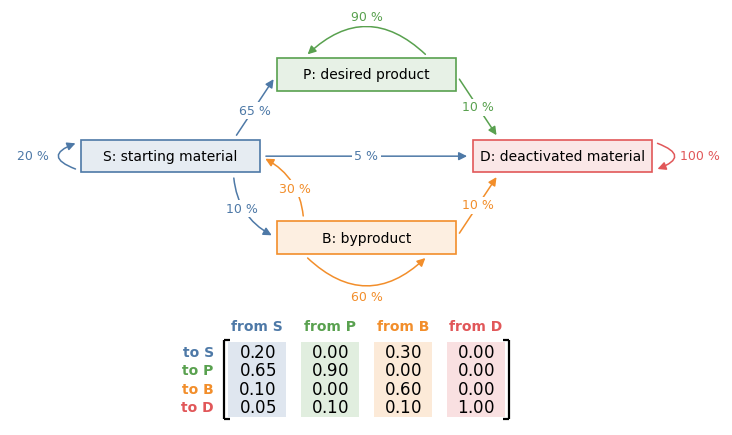

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba
from matplotlib.patches import FancyArrowPatch, Rectangle

BOX_WIDTH = 2.75
BOX_HEIGHT = 0.50
STATE_ORDER = ['S', 'P', 'B', 'D']
STATE_COLORS = {
    'S': '#4e79a7',
    'P': '#59a14f',
    'B': '#f28e2b',
    'D': '#e15759',
}
TRANSITION_MATRIX = np.array([
    [0.20, 0.00, 0.30, 0.00],  # to S
    [0.65, 0.90, 0.00, 0.00],  # to P
    [0.10, 0.00, 0.60, 0.00],  # to B
    [0.05, 0.10, 0.10, 1.00],  # to D
])
STATES = {
    'S': {'label': 'S: starting material', 'xy': (0.0, 0.0)},
    'P': {'label': 'P: desired product', 'xy': (3.0, 1.25)},
    'B': {'label': 'B: byproduct', 'xy': (3.0, -1.25)},
    'D': {'label': 'D: deactivated material', 'xy': (6.0, 0.0)},
}
TRANSITIONS = [
    ('S', 'S', '20 %', 'left_bottom', 'left_top', -1.50, (-2.10, 0.00)),
    ('S', 'P', '65 %', 'top_right', 'left', 0.00, (0.00, -0.05)),
    ('S', 'B', '10 %', 'bottom_right', 'left', 0.30, (-0.20, -0.05)),
    ('S', 'D', '5 %', 'right', 'left', 0.00, (0.00, 0.00)),
    ('P', 'P', '90 %', 'top_right', 'top_left', 0.50, (0.00, 0.88)),
    ('P', 'D', '10 %', 'right', 'top_left', 0.00, (0.00, 0.00)),
    ('B', 'S', '30 %', 'top_left', 'right', 0.30, (0.20, 0.00)),
    ('B', 'B', '60 %', 'bottom_left', 'bottom_right', 0.50, (0.00, -0.90)),
    ('B', 'D', '10 %', 'right', 'bottom_left', 0.00, (0.00, 0.00)),
    ('D', 'D', '100 %', 'right_top', 'right_bottom', -1.50, (2.10, 0.00)),
]

fig = plt.figure(figsize=(9.2, 5.4))
gs = fig.add_gridspec(2, 1, height_ratios=[3.6, 1.25], hspace=0.10)
ax = fig.add_subplot(gs[0])
ax_matrix = fig.add_subplot(gs[1])


for key, state in STATES.items():
    x, y = state['xy']
    box = Rectangle(
        (x - BOX_WIDTH / 2, y - BOX_HEIGHT / 2),
        BOX_WIDTH,
        BOX_HEIGHT,
        facecolor=to_rgba(STATE_COLORS[key], 0.14),
        edgecolor=STATE_COLORS[key],
        linewidth=1.2,
    )
    ax.add_patch(box)
    ax.text(x, y, state['label'], ha='center', va='center', fontsize=10)

def anchor_point(state, anchor):
    x, y = STATES[state]['xy']
    offsets = {
        "left": (-BOX_WIDTH / 2, 0.0),
        "right": (BOX_WIDTH / 2, 0.0),
        "top_left": (-0.35 * BOX_WIDTH, BOX_HEIGHT / 2),
        "top_right": (0.35 * BOX_WIDTH, BOX_HEIGHT / 2),
        "bottom_left": (-0.35 * BOX_WIDTH, -BOX_HEIGHT / 2),
        "bottom_right": (0.35 * BOX_WIDTH, -BOX_HEIGHT / 2),
        "left_top": (-BOX_WIDTH / 2, 0.45 * BOX_HEIGHT),
        "left_bottom": (-BOX_WIDTH / 2, -0.45 * BOX_HEIGHT),
        "right_top": (BOX_WIDTH / 2, 0.45 * BOX_HEIGHT),
        "right_bottom": (BOX_WIDTH / 2, -0.45 * BOX_HEIGHT),
    }
    dx, dy = offsets[anchor]
    return x + dx, y + dy


def add_transition(source, target, label, source_anchor, target_anchor, curve, label_offset):
    x0, y0 = STATES[source]['xy']
    x1, y1 = STATES[target]['xy']
    start = anchor_point(source, source_anchor)
    end = anchor_point(target, target_anchor)
    color = STATE_COLORS[source]
    if source == target:
        arrow = FancyArrowPatch(
            start,
            end,
            connectionstyle=f'arc3,rad={curve}',
            arrowstyle='-|>',
            mutation_scale=12,
            linewidth=1.1,
            color=color,
            shrinkA=4,
            shrinkB=4,
        )
        label_x = x0 + label_offset[0]
        label_y = y0 + label_offset[1]
    else:
        arrow = FancyArrowPatch(
            start,
            end,
            connectionstyle=f'arc3,rad={curve}',
            arrowstyle='-|>',
            mutation_scale=12,
            linewidth=1.1,
            color=color,
            shrinkA=4,
            shrinkB=4,
        )
        label_x = 0.5 * (start[0] + end[0]) + label_offset[0]
        label_y = 0.5 * (start[1] + end[1]) + label_offset[1]
    
    ax.add_patch(arrow)
    ax.text(label_x, label_y, label, ha='center', va='center', fontsize=9,
            color=color,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 1.5})

for transition in TRANSITIONS:
    add_transition(*transition)

ax.set_xlim(-2.25, 8.25)
ax.set_ylim(-2.25, 2.25)
ax.set_aspect('equal')
ax.axis('off')

n = len(STATE_ORDER)
column_spacing = 0.25
column_width = 0.20
number_offset = 0.00
x_positions = np.arange(n) * column_spacing

for column, state in enumerate(STATE_ORDER):
    x = x_positions[column]
    ax_matrix.add_patch(Rectangle(
        (x - column_width / 2, -0.5),
        column_width,
        n,
        facecolor=to_rgba(STATE_COLORS[state], 0.18),
        edgecolor='none',
    ))
    ax_matrix.text(x, n + 0.00, f'from {state}',
                   ha='center', va='bottom', fontsize=10,
                   color=STATE_COLORS[state], weight='bold')

for row, state in enumerate(STATE_ORDER):
    y = n - 1 - row
    ax_matrix.text(x_positions[0] - 0.15, y, f'to {state}', ha='right', va='center',
                   fontsize=10, color=STATE_COLORS[state], weight='bold')
    for column, value in enumerate(TRANSITION_MATRIX[row]):
        ax_matrix.text(x_positions[column] + number_offset, y, f'${value:.2f}$',
                       ha='center', va='center', fontsize=12, color='black')

left = x_positions[0] - column_width / 2 - 0.015
right = x_positions[-1] + column_width / 2 + 0.015
bottom = -0.64
top = n - 1 + 0.64
tick = 0.02
bracket_style = {'color': 'black', 'linewidth': 1.6, 'solid_capstyle': 'butt'}
ax_matrix.plot([left, left], [bottom, top], **bracket_style)
ax_matrix.plot([left, left + tick], [top, top], **bracket_style)
ax_matrix.plot([left, left + tick], [bottom, bottom], **bracket_style)
ax_matrix.plot([right, right], [bottom, top], **bracket_style)
ax_matrix.plot([right - tick, right], [top, top], **bracket_style)
ax_matrix.plot([right - tick, right], [bottom, bottom], **bracket_style)

ax_matrix.set_xlim(x_positions[0] - 0.85, x_positions[-1] + 0.85)
ax_matrix.set_ylim(-0.95, n + 0.55)
ax_matrix.axis('off')
plt.show()

This kind of process is called a [Markov process](wiki:Markov_process).
The matrix describing the transitions is called a [transition matrix](wiki:State-transition_matrix).
Now we code this matrix in Python.

In [6]:
labels = np.array(['S', 'P', 'B', 'D'])

transition = np.array([
    [0.20, 0.00, 0.30, 0.00],  # to S
    [0.65, 0.90, 0.00, 0.00],  # to P
    [0.10, 0.00, 0.60, 0.00],  # to B
    [0.05, 0.10, 0.10, 1.00],  # to D
])

print(transition.sum(axis=0))

[1. 1. 1. 1.]


The column sums are all equal to one. This means that all material from each
state is redistributed somewhere after one cycle; no material is created or
lost outside the four-state model.

Now denote the transition matrix as $\bm{T}$. A state can be represented as a vector $\vec{x}$,
where each entry gives the fraction of material in one of the four pools,
in the order `S`, `P`, `B`, `D`.
If we start from pure starting material, the composition after one cycle is
given by $\bm{T} \vec{x}$.

In [7]:
x0 = np.array([1.0, 0.0, 0.0, 0.0])
print(transition @ x0)

[0.2  0.65 0.1  0.05]


This works exactly as expected: the first column of the transition matrix gives the
fractions of material in each pool after one cycle, starting from pure `S`.
If we start from a different composition, we can still use the same
matrix-vector product to find the new composition after one cycle.

Now what happens if we repeat this process many times? We would get
```{math}
:enumerated: true
:label: eq:transition_k
\vec{x}_k = \underbrace{\bm{T}\bm{T}\cdots\bm{T}}_{k \text{ times}}\, \vec{x}_0 = \bm{T}^k \vec{x}_0 \, .
```

This formula should look familiar: it is exactly the repeated matrix-vector
multiplication used in power iteration, Eq.&nbsp;{eq}`eq:power_iteration`, except
that we do not normalise the vector at each step. Here, the column sums of
$\bm{T}$ are equal to one, so the total material fraction is preserved.

This means that we are dealing with an eigenvalue problem.
In fact, if the process converges to a steady state, then, because
$\bm{T}\vec{x}_k = \vec{x}_{k+1}$, taking the limit $k \to \infty$ gives
```{math}
:enumerated: true
:label: eq:steady_state
\bm{T}\vec{x}_\infty = \vec{x}_\infty \,,
```
which is exactly an eigenvalue equation with eigenvalue $\lambda = 1$.

Therefore, we should be able to use `power_iteration` to find the steady state
of this process. Let's try it out.

First, we do the iteration described by Eq.&nbsp;{eq}`eq:transition_k`.

In [8]:
x = np.copy(x0)

for _ in range(200):
    x = transition @ x
print('stationary composition:', x)

stationary composition: [3.93825113e-37 7.64300237e-10 6.09871178e-37 9.99999999e-01]


Now we compute the stationary composition by solving Eq.&nbsp;{eq}`eq:steady_state` using power iteration.

In [9]:
lambda_pi, x_pi, niter_pi = power_iteration(transition)
print('eigenvalue:', lambda_pi)
print('stationary composition:', x_pi)
print('number of iterations:', niter_pi)

eigenvalue: 1.0000000000907099
stationary composition: [7.65061621e-37 9.07099200e-10 1.18476201e-36 1.00000000e+00]
number of iterations: 198


We can also apply the QR algorithm to the transition matrix. 

In [10]:
eigvals_qr, vecs_qr, niter_qr = qr_algorithm(transition)
print('eigenvalues:', eigvals_qr)
print('Schur vectors:\n', vecs_qr)

eigenvalues: [1.         0.9        0.66457513 0.13542487]
Schur vectors:
 [[ 2.23060544e-17  2.41874353e-16  5.42476807e-01  8.40070779e-01]
 [ 9.43584339e-10 -1.00000000e+00 -2.79175052e-16  1.22091593e-16]
 [-4.80916117e-16  7.36864240e-17  8.40070779e-01 -5.42476807e-01]
 [ 1.00000000e+00  9.43584163e-10  8.49511653e-16 -1.87073953e-16]]


We see an eigenvalue of 1. Since the transition matrix is not normal, the QR
iteration gives [*Schur vectors*](wiki:Schur_decomposition) rather than, in
general, eigenvectors. In this example, the eigenvalue 1 appears first in the
Schur form. The first Schur vector is therefore also the corresponding
eigenvector, so we can read off the stationary composition from the first
column of `vecs_qr`.

The other eigenvalues have absolute values smaller than 1 and are related to
the timescales of some relaxation processes.
The exact relationship is beyond the scope of this section; interested readers
can refer to literature on Markov processes, such as
[*A Tutorial on the Spectral Theory of Markov Chains*](https://direct.mit.edu/neco/article/35/11/1713/117578/A-Tutorial-on-the-Spectral-Theory-of-Markov-Chains).

Finally, we compare the result with NumPy's general eigenvalue solver,
[`np.linalg.eig`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html).

In [11]:
eigvals_np, eigvecs_np = np.linalg.eig(transition)
print('eigenvalues:', eigvals_np)
print('eigenvectors:\n', eigvecs_np)

eigenvalues: [1.         0.9        0.66457513 0.13542487]
eigenvectors:
 [[ 0.          0.          0.30060883  0.75093436]
 [ 0.          0.70710678 -0.82997068 -0.63840336]
 [ 0.          0.          0.46551795 -0.16163895]
 [ 1.         -0.70710678  0.0638439   0.04910795]]


All methods give the same stationary composition, namely the eigenvector
corresponding to the eigenvalue 1. Interpreting this vector in terms of material
fractions, we see that all material is eventually lost to the deactivated
state `D`. This is chemically rather grim, but it is also intuitive on second
thought: `D` is the only absorbing state. Material can enter it from `S`, `P`,
and `B`, but it never leaves. The stationary composition is therefore a
consequence of repeatedly applying the transition matrix.


## Testing the QR Algorithm

As a final check, we test our QR algorithm on a symmetric matrix, so that we
also have a clear reference for the eigenvectors. We start by generating a
random matrix and then symmetrise it by adding its transpose.

In [12]:
NDIM = 8

rng = np.random.default_rng(12)
a = rng.uniform(size=(NDIM, NDIM))
a = a + a.T

Then we apply our QR algorithm and
[`np.linalg.eigh`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html)
to this matrix.

:::{note} `np.linalg.eigh`
`np.linalg.eigh` is NumPy's specialised eigenvalue solver for real symmetric
or complex Hermitian matrices. This is usually faster and more accurate
than the general solver `np.linalg.eig` for such matrices.
:::

:::{warning}
Do not use `np.linalg.eigh` for a general non-symmetric or non-Hermitian
matrix. It assumes this special structure and can silently return incorrect
results if the input does not have it. For a general square matrix, use
`np.linalg.eig`.
:::

`np.linalg.eigh` returns the eigenvalues in ascending order, whereas our QR
algorithm does not guarantee this ordering. We therefore use
[`np.argsort`](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html)
to obtain the indices that would sort the QR eigenvalues. We then use these
indices to sort both the QR eigenvalues and the corresponding eigenvectors.


In [13]:
eigvals_qr, eigvecs_qr, niter_qr = qr_algorithm(a)
eigvals_ref, eigvecs_ref = np.linalg.eigh(a)

idx_qr = np.argsort(eigvals_qr)
eigvals_qr = eigvals_qr[idx_qr]
eigvecs_qr = eigvecs_qr[:, idx_qr]

print('QR eigenvalues:')
print(eigvals_qr)
print('eigh eigenvalues:')
print(eigvals_ref)
print('agree:', np.allclose(eigvals_qr, eigvals_ref))

QR eigenvalues:
[-2.09506301 -1.30896807 -0.71115122  0.4015567   1.11413307  1.27097322
  1.82051215  8.74452471]
eigh eigenvalues:
[-2.09506301 -1.30896807 -0.71115122  0.4015567   1.11413307  1.27097322
  1.82051215  8.74452471]
agree: True


To compare the eigenvectors, let $\bm{V}_{\mathrm{QR}}$ contain
the eigenvectors from our QR algorithm and $\bm{V}_{\mathrm{ref}}$
those from `np.linalg.eigh`, both arranged according to the sorted eigenvalues.
We then compute the absolute overlap matrix
$$
\bm{O} = \left|\bm{V}_{\mathrm{QR}}^\dagger\bm{V}_{\mathrm{ref}}\right| \, .
$$

If the eigenvectors agree, $\bm{O}$ should be close to the identity matrix.

:::{tip} Why don't we compare the eigenvectors directly?
:class: dropdown
Eigenvectors have an arbitrary scaling factor.
If $\vec{v}$ is an eigenvector, then $\alpha\vec{v}$ with $\alpha \in \mathbb{C}$
is also an eigenvector for the same eigenvalue.
Even though our QR algorithm and `np.linalg.eigh` return normalised eigenvectors,
the sign (or more generally, the phase) is still arbitrary.
Therefore, we construct the overlap matrix by taking the scalar product
of the eigenvectors from both algorithms. If the two sets of eigenvectors
are the same up to a phase, the overlap matrix is diagonal with entries of
unit magnitude.
:::

In [14]:
overlap = np.abs(eigvecs_qr.conj().T @ eigvecs_ref)
print(overlap)
print('close to identity:', np.allclose(overlap, np.eye(NDIM), atol=1e-6))

[[1.00000000e+00 1.66533454e-15 9.92261828e-16 1.07552856e-16
  1.52655666e-16 4.16333634e-16 7.77156117e-16 3.88578059e-16]
 [8.46545056e-16 1.00000000e+00 1.83186799e-15 5.55111512e-17
  5.55111512e-17 3.77174680e-11 4.57966998e-16 6.38378239e-16]
 [5.62050406e-16 1.22384741e-15 1.00000000e+00 1.22124533e-15
  2.77555756e-17 5.55111512e-17 1.11022302e-16 6.66133815e-16]
 [8.11850587e-16 4.99600361e-16 1.66533454e-16 1.00000000e+00
  5.55111512e-17 1.24900090e-16 2.77555756e-17 3.33066907e-16]
 [2.63677968e-16 6.10622664e-16 3.05311332e-16 9.71445147e-16
  1.00000000e+00 5.88418203e-15 5.55111512e-17 6.52256027e-16]
 [6.10622664e-16 3.77169867e-11 2.91433544e-16 6.45317133e-16
  7.82707232e-15 1.00000000e+00 1.13797860e-15 1.55431223e-15]
 [7.21644966e-16 1.24900090e-16 3.53883589e-16 2.49800181e-16
  5.62050406e-16 1.30451205e-15 1.00000000e+00 3.19189120e-16]
 [2.49800181e-16 5.55111512e-17 2.22044605e-16 1.73472348e-16
  2.63677968e-16 5.55111512e-17 1.94289029e-16 1.00000000e+00]]

The self-implemented QR algorithm is useful for understanding the method, but
for real scientific work we should use the library implementation. NumPy's
`eigh` uses algorithms that are more robust and efficient than the basic
unshifted QR iteration implemented here.

## Self-Study Questions

1. In the reaction path network, why does a stationary composition satisfy
   $\bm{T}\vec{x} = \vec{x}$? How is this related to the fact that the columns
   of the transition matrix sum to one?
2. In power iteration, the vector is normalised after each matrix-vector
   multiplication. Why is this useful in general, and why was this unnecessary
   in the reaction path network example?
3. Why do we accumulate the matrices `q_k` in `vecs = vecs @ q_k`? Under which
   condition can the columns of `vecs` be interpreted as approximate eigenvectors?
4. Why is `np.linalg.eigh` the appropriate reference function for the random
   symmetric matrix, while `np.linalg.eig` is the appropriate reference
   function for the reaction transition matrix?